processing month 2018-01
processing month 2018-02
processing month 2018-03
processing month 2018-04
processing month 2018-05
processing month 2018-06
processing month 2018-07
processing month 2018-08
processing month 2018-09
processing month 2018-10
processing month 2018-11
processing month 2018-12
processing month 2019-01
processing month 2019-02
processing month 2019-03
processing month 2019-04
processing month 2019-05
processing month 2019-06


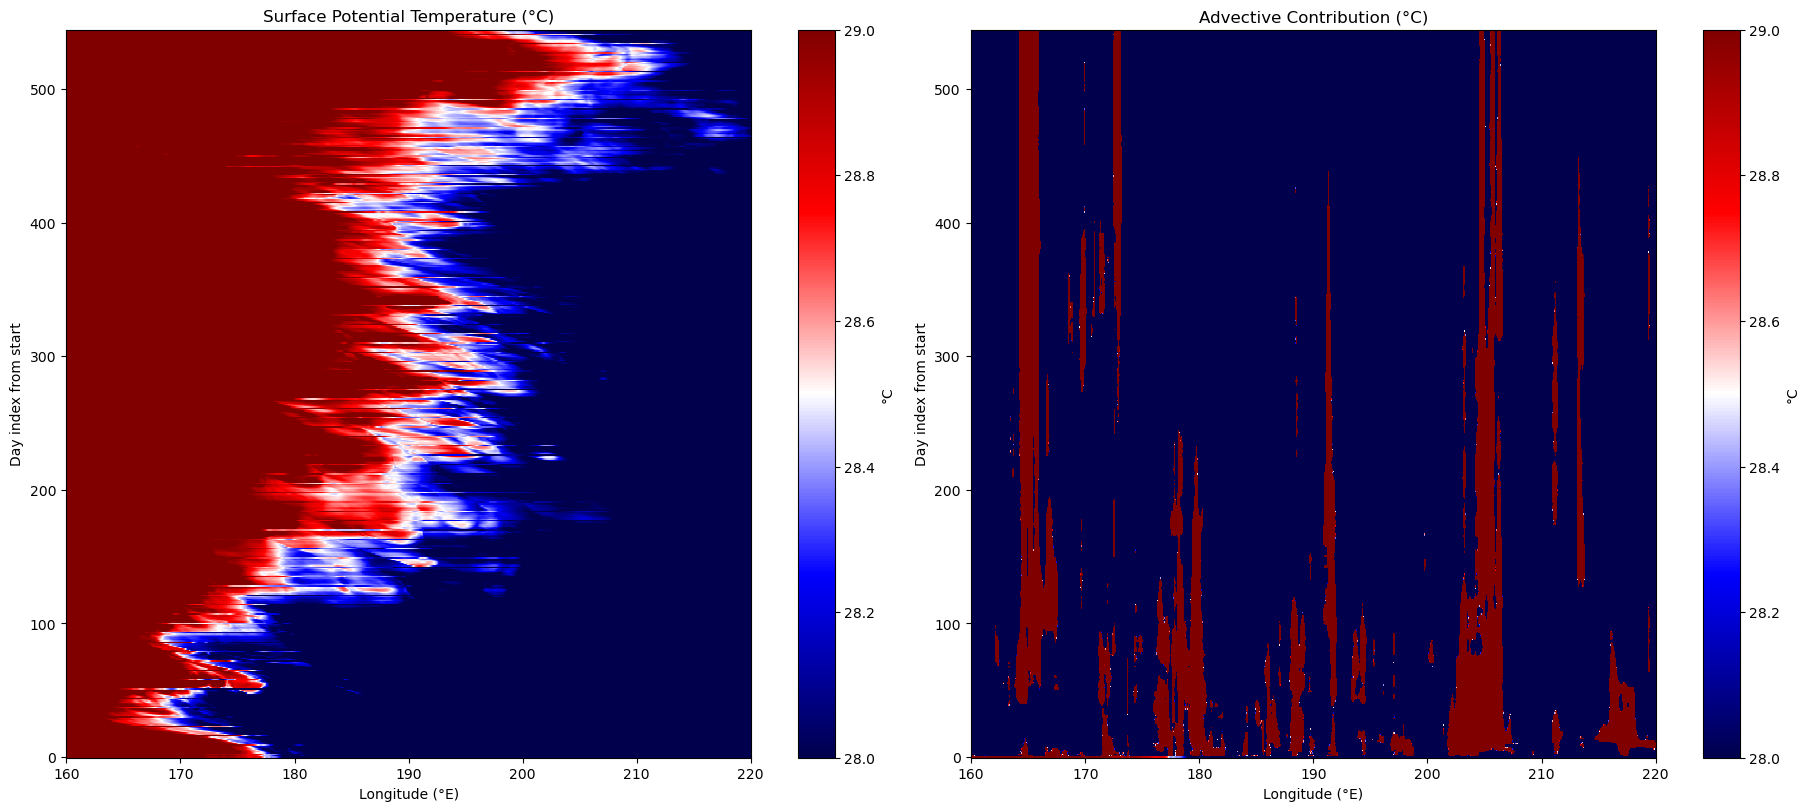

In [1]:
import os
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
folder = '/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/'

start_date = datetime(2018, 1, 1)
end_date   = datetime(2019, 6, 29)

# longitude window (degrees, likely 0–360 on GLORYS)
LON_MIN = 160.0
LON_MAX = 220.0

# latitude to sample (choose 0 for equator; change if needed)
LAT_TARGET = 0.0

# ----------------------------
# HELPERS
# ----------------------------
def date_list(d0, d1):
    n = (d1 - d0).days + 1
    return [d0 + timedelta(days=i) for i in range(n)]

def open_flux_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_trendWithFluxes_{d:%Y-%m-%d}.nc')

def open_var_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_{d:%Y-%m-%d}.nc')

# ----------------------------
# INITIAL METADATA READ (to get lat/lon & indices)
# ----------------------------
first_vars = xr.open_dataset(open_var_path(start_date))
lat = first_vars['latitude'].values
lon = first_vars['longitude'].values

# nearest latitude index to LAT_TARGET
lat_index = int(np.argmin(np.abs(lat - LAT_TARGET)))

# longitude slice indices
lon_idx_start = int(np.argmin(np.abs(lon - LON_MIN)))
lon_idx_end   = int(np.argmin(np.abs(lon - LON_MAX)))

# depth index

depthIndex = 2

# ensure start <= end (no wrap handling needed for 160E–220E on 0–360 grid)
if lon_idx_start > lon_idx_end:
    lon_idx_start, lon_idx_end = lon_idx_end, lon_idx_start

# keep a copy of lon subset for plotting
lon_sub = lon[lon_idx_start:lon_idx_end + 1]

first_vars.close()

# ----------------------------
# GATHER DAILY SLICES
# ----------------------------
temps = []       # list of arrays with shape (nx,)
advecs = []      # list of arrays with shape (nx,)
dates = []       # for plotting / reference

for d in date_list(start_date, end_date):
    if d.day == 1:
        print(f'processing month {d:%Y-%m}')

    var_path = open_var_path(d)
    flux_path = open_flux_path(d)

    if not (os.path.exists(var_path) and os.path.exists(flux_path)):
        # skip missing days
        continue

    ds_vars  = xr.open_dataset(var_path)
    ds_flux  = xr.open_dataset(flux_path)

    try:
        # Select surface (depth=depthIndex), chosen latitude, lon slice, and first (only) time
        # Shapes: (time=1, lon_slice) -> squeeze to (lon_slice,)
        T = ds_vars['thetao'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                   longitude=slice(lon_idx_start, lon_idx_end + 1)).values
        ADV = ds_flux['thetao_flux_total'].isel(time=0, depth=depthIndex, latitude=lat_index,
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).values

        temps.append(T)
        advecs.append(ADV)
        dates.append(d)
    finally:
        ds_vars.close()
        ds_flux.close()

# Convert lists to arrays
# Resulting shapes: (ndays, nx)
temp = np.asarray(temps)
advection = np.asarray(advecs)

if temp.size == 0:
    raise RuntimeError("No data gathered. Check file paths and date range.")

# ----------------------------
# CUMULATIVE ADVECTIVE CONTRIBUTION
# advection is a tendency (per second). Integrate in time (daily steps) to get contribution.
# ----------------------------
SECONDS_PER_DAY = 24 * 3600

# integrate tendency
cum = np.cumsum(advection * SECONDS_PER_DAY, axis=0)          # shape (ndays, nx)

# shift so that day 0 has zero integrated change (no prior day)
cum_shifted = np.vstack([np.zeros_like(cum[:1]), cum[:-1]])    # (ndays, nx)

# advective-only reconstruction aligned with the *same* day as temp
adv_contribution = temp[0, :][None, :] + cum_shifted           # (ndays, nx)

# ----------------------------
# PLOTTING
# ----------------------------
fig, axes = plt.subplots(ncols=2, figsize=(18, 8), constrained_layout=True)
cmap = plt.cm.seismic
vmin, vmax = 28.0, 29.0

# x-axis as longitude indices (or degrees). Using degrees is clearer:
X = lon_sub  # shape (nx,)
Y = np.arange(temp.shape[0])  # day index

# Plot temperature
im0 = axes[0].pcolormesh(X, Y, temp, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
axes[0].set_title('Surface Potential Temperature (°C)')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Day index from start')
fig.colorbar(im0, ax=axes[0], label='°C')

# Plot advective-only reconstruction
im1 = axes[1].pcolormesh(X, Y, adv_contribution, vmin=vmin, vmax=vmax, cmap=cmap, shading='auto')
axes[1].set_title('Advective Contribution (°C)')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Day index from start')
fig.colorbar(im1, ax=axes[1], label='°C')



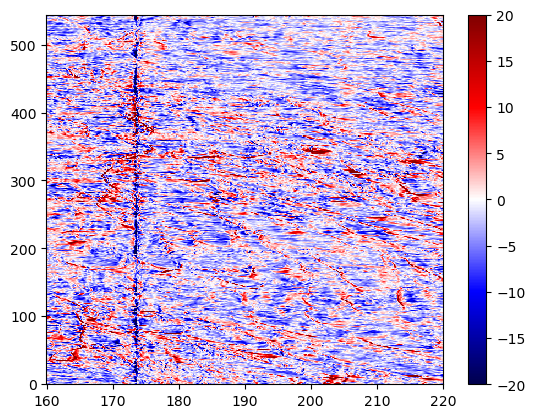

In [15]:
v = 20#0.0002
plt.pcolormesh(X, Y, advection*3600*24, vmin=-v, vmax=v, cmap=cmap, shading='auto')
plt.colorbar()

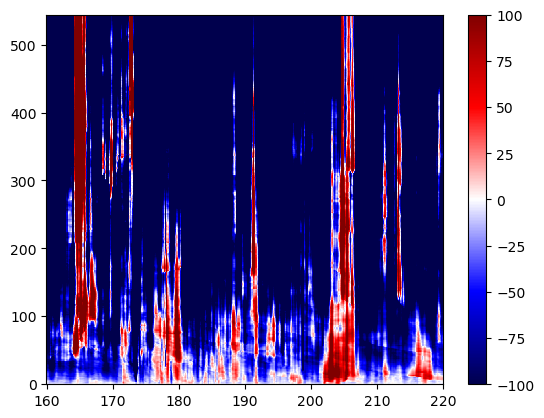

In [12]:
v = 100
tc = 0 # 28.5
plt.pcolormesh(X, Y, cum,  vmin=tc-v, vmax=tc+v, cmap=cmap, shading='auto')
plt.colorbar()

In [3]:

latIndex

NameError: name 'latIndex' is not defined

In [ ]:
plt.figure(figsize=(20, 6))
vars_ds.thetao.isel(depth=depthIndex).plot(x='longitude', y='latitude', vmin = 28, vmax = 29, cmap= 'seismic')

In [16]:
ds_flux

<xarray.Dataset>
Dimensions:             (time: 1, depth: 28, latitude: 385, longitude: 2245)
Coordinates:
  * time                (time) datetime64[ns] 2019-06-29T12:00:00
  * depth               (depth) float32 0.494 1.541 2.646 ... 186.1 222.5 266.0
  * latitude            (latitude) float32 -16.0 -15.92 -15.83 ... 15.92 16.0
  * longitude           (longitude) float32 109.0 109.1 109.2 ... 295.9 296.0
Data variables: (12/21)
    trend_thetao        (time, depth, latitude, longitude) float32 ...
    tend_so             (time, depth, latitude, longitude) float32 ...
    thetao_flux_horiz   (latitude, longitude, time, depth) float64 ...
    thetao_flux_vert    (time, depth, latitude, longitude) float64 ...
    thetao_flux_total   (latitude, longitude, time, depth) float64 ...
    thetao_flux_east    (latitude, longitude, time, depth) float64 ...
    ...                  ...
    so_flux_west        (latitude, longitude, time, depth) float64 ...
    so_flux_north       (latitude, longitude, time, depth) float64 ...
    so_flux_south       (latitude, longitude, time, depth) float64 ...
    so_flux_bottom      (time, depth, latitude, longitude) float64 ...
    so_flux_top         (time, depth, latitude, longitude) float64 ...
    dVol                (time, depth, latitude, longitude) float64 ...

In [ ]:
fluxes_ds